### **Importing Libraries and Loading Dataset**


**Purpose**: To import required libraries and load the dataset into a DataFrame.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from mpl_toolkits.mplot3d import Axes3D


# Load the dataset
data = pd.read_csv('healthcare-dataset-stroke-data.csv')

## Exploratory Data Analysis (EDA)

**Purpose**: Visualize and understand the distribution of variables and their relationship with the target variable `stroke`.

### 1. Target Variable Distribution

**Purpose**: Examine the class balance of the `stroke` column to detect any imbalance between stroke and non-stroke cases.

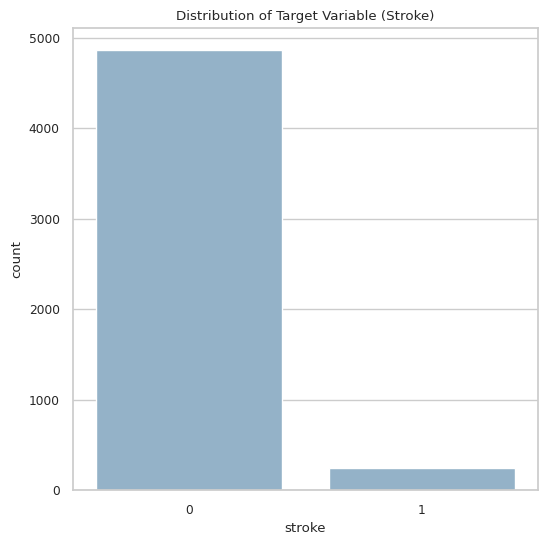

In [ ]:
# Set the style of all graphs to seaborn
sns.set_style("whitegrid")

# Plot the target variable 'stroke'
plt.figure(figsize=(6, 6))
sns.countplot(x=data['stroke'])
plt.title('Distribution of Target Variable (Stroke)')
plt.show()

### 2. Categorical Variable Distributions

**Purpose**: Plot bar charts for all categorical features to understand their frequency and spread across categories.

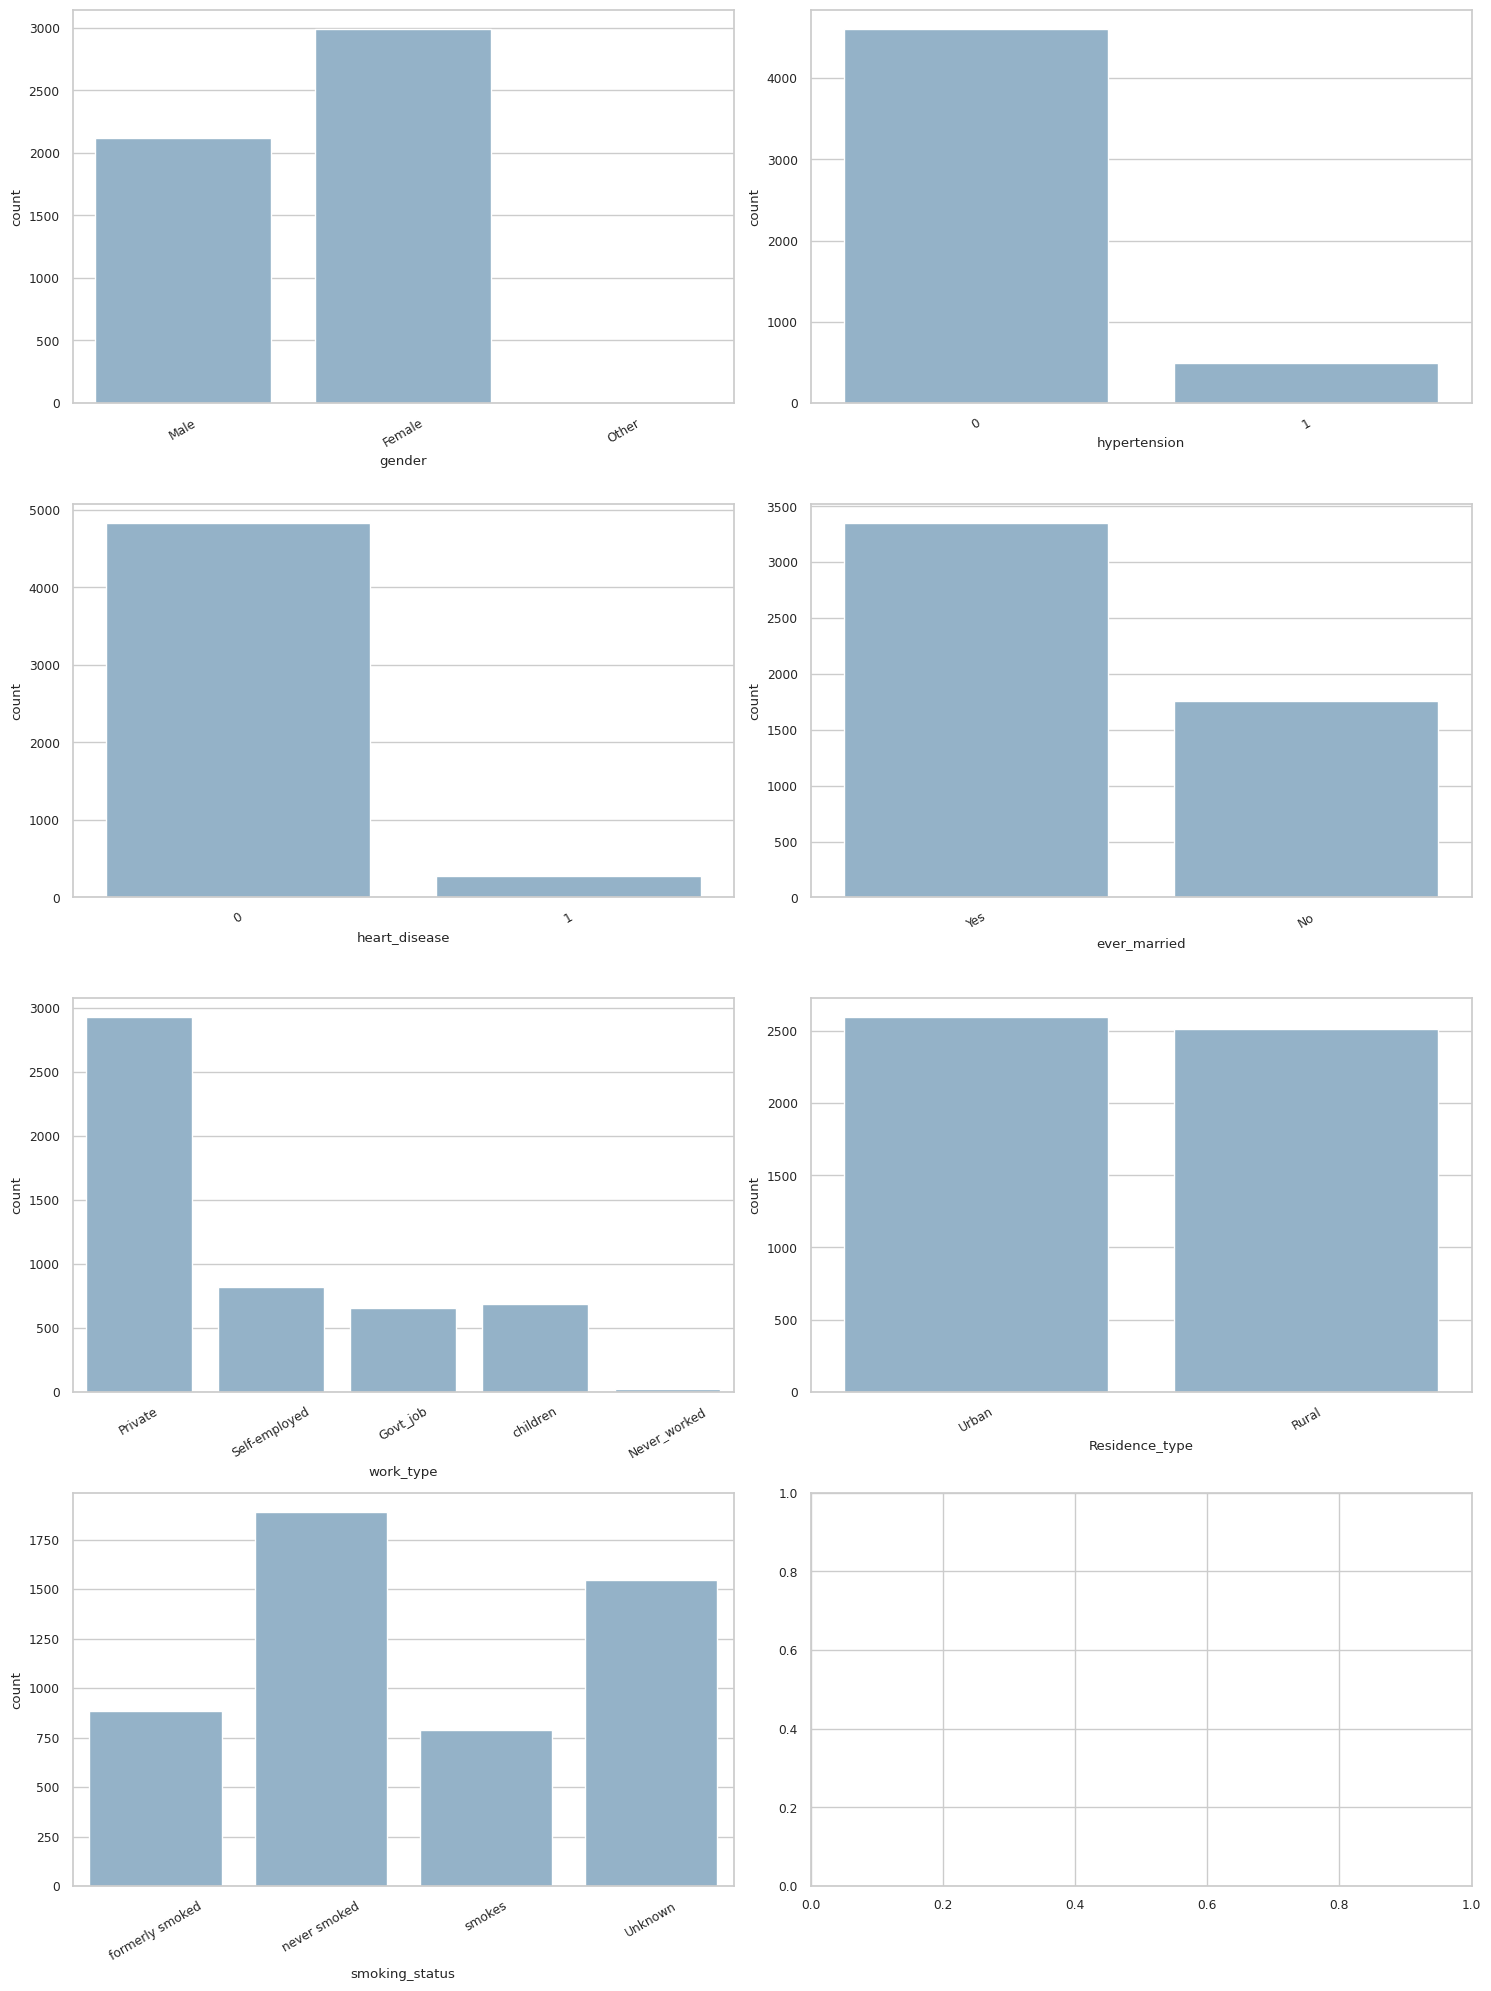

In [ ]:
# List of categorical variables
categorical_variables = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Plotting the bar plots
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

for var, subplot in zip(categorical_variables, axs.flatten()):
    sns.countplot(x=var, data=data, ax=subplot)
    for label in subplot.get_xticklabels():
        label.set_rotation(30)

plt.tight_layout()
plt.show()

### 3. Continuous Variable Distributions

**Purpose**: Visualize the distribution of continuous variables (`age`, `avg_glucose_level`, `bmi`) using histograms with KDE curves.

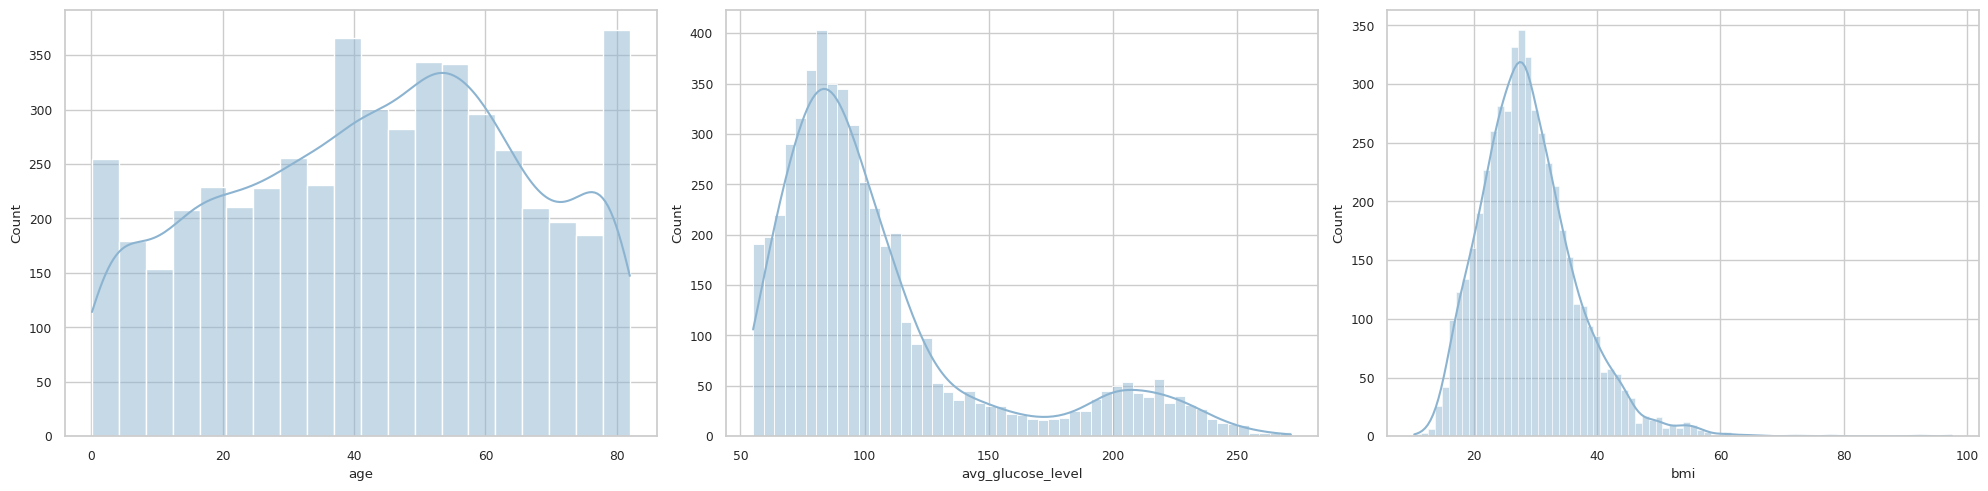

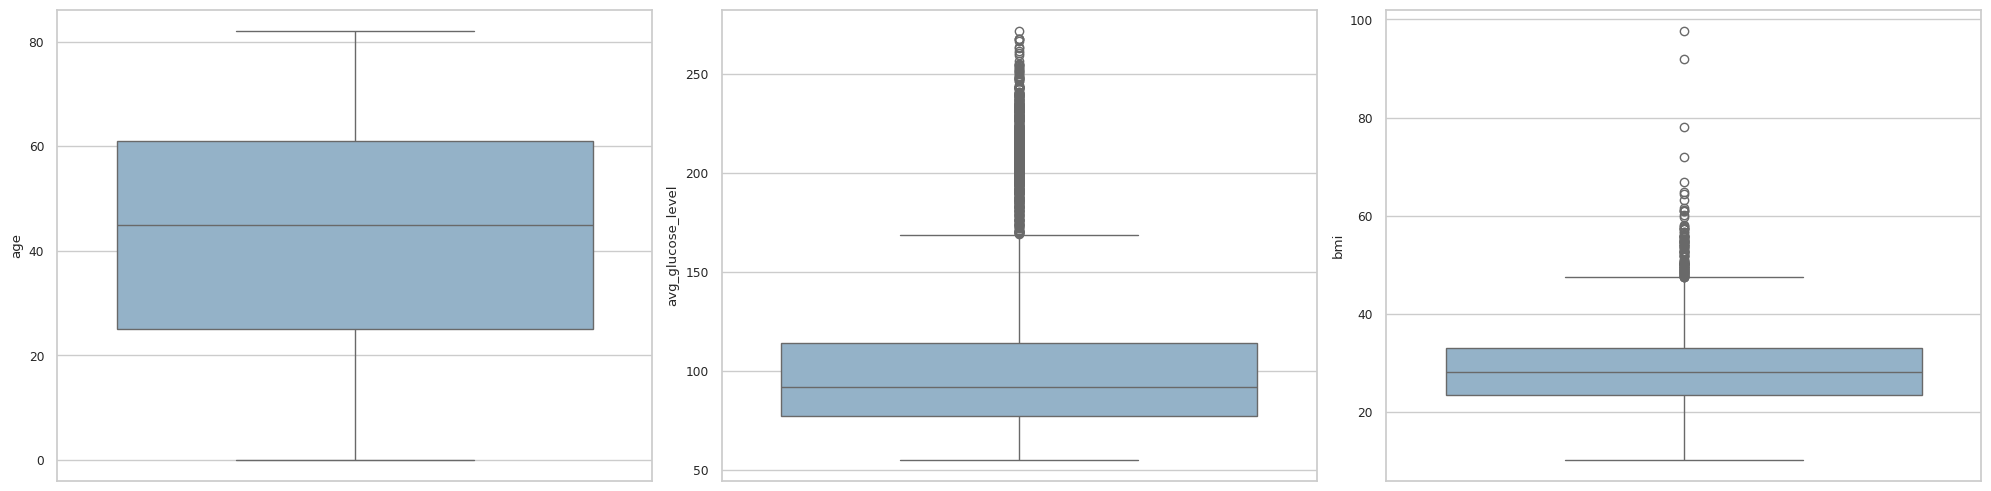

In [ ]:
# List of continuous variables
continuous_variables = ['age', 'avg_glucose_level', 'bmi']

# Plot the histograms for continuous variables
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for var, subplot in zip(continuous_variables, axs.flatten()):
    sns.histplot(data[var], kde=True, ax=subplot)

plt.tight_layout()
plt.show()

# Plot the boxplots for continuous variables
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for var, subplot in zip(continuous_variables, axs.flatten()):
    sns.boxplot(data[var], ax=subplot)

plt.tight_layout()
plt.show()

### 4. Categorical Variables vs Stroke

**Purpose**: Compare categorical feature distributions against the target variable to identify which categories are associated with higher stroke rates.

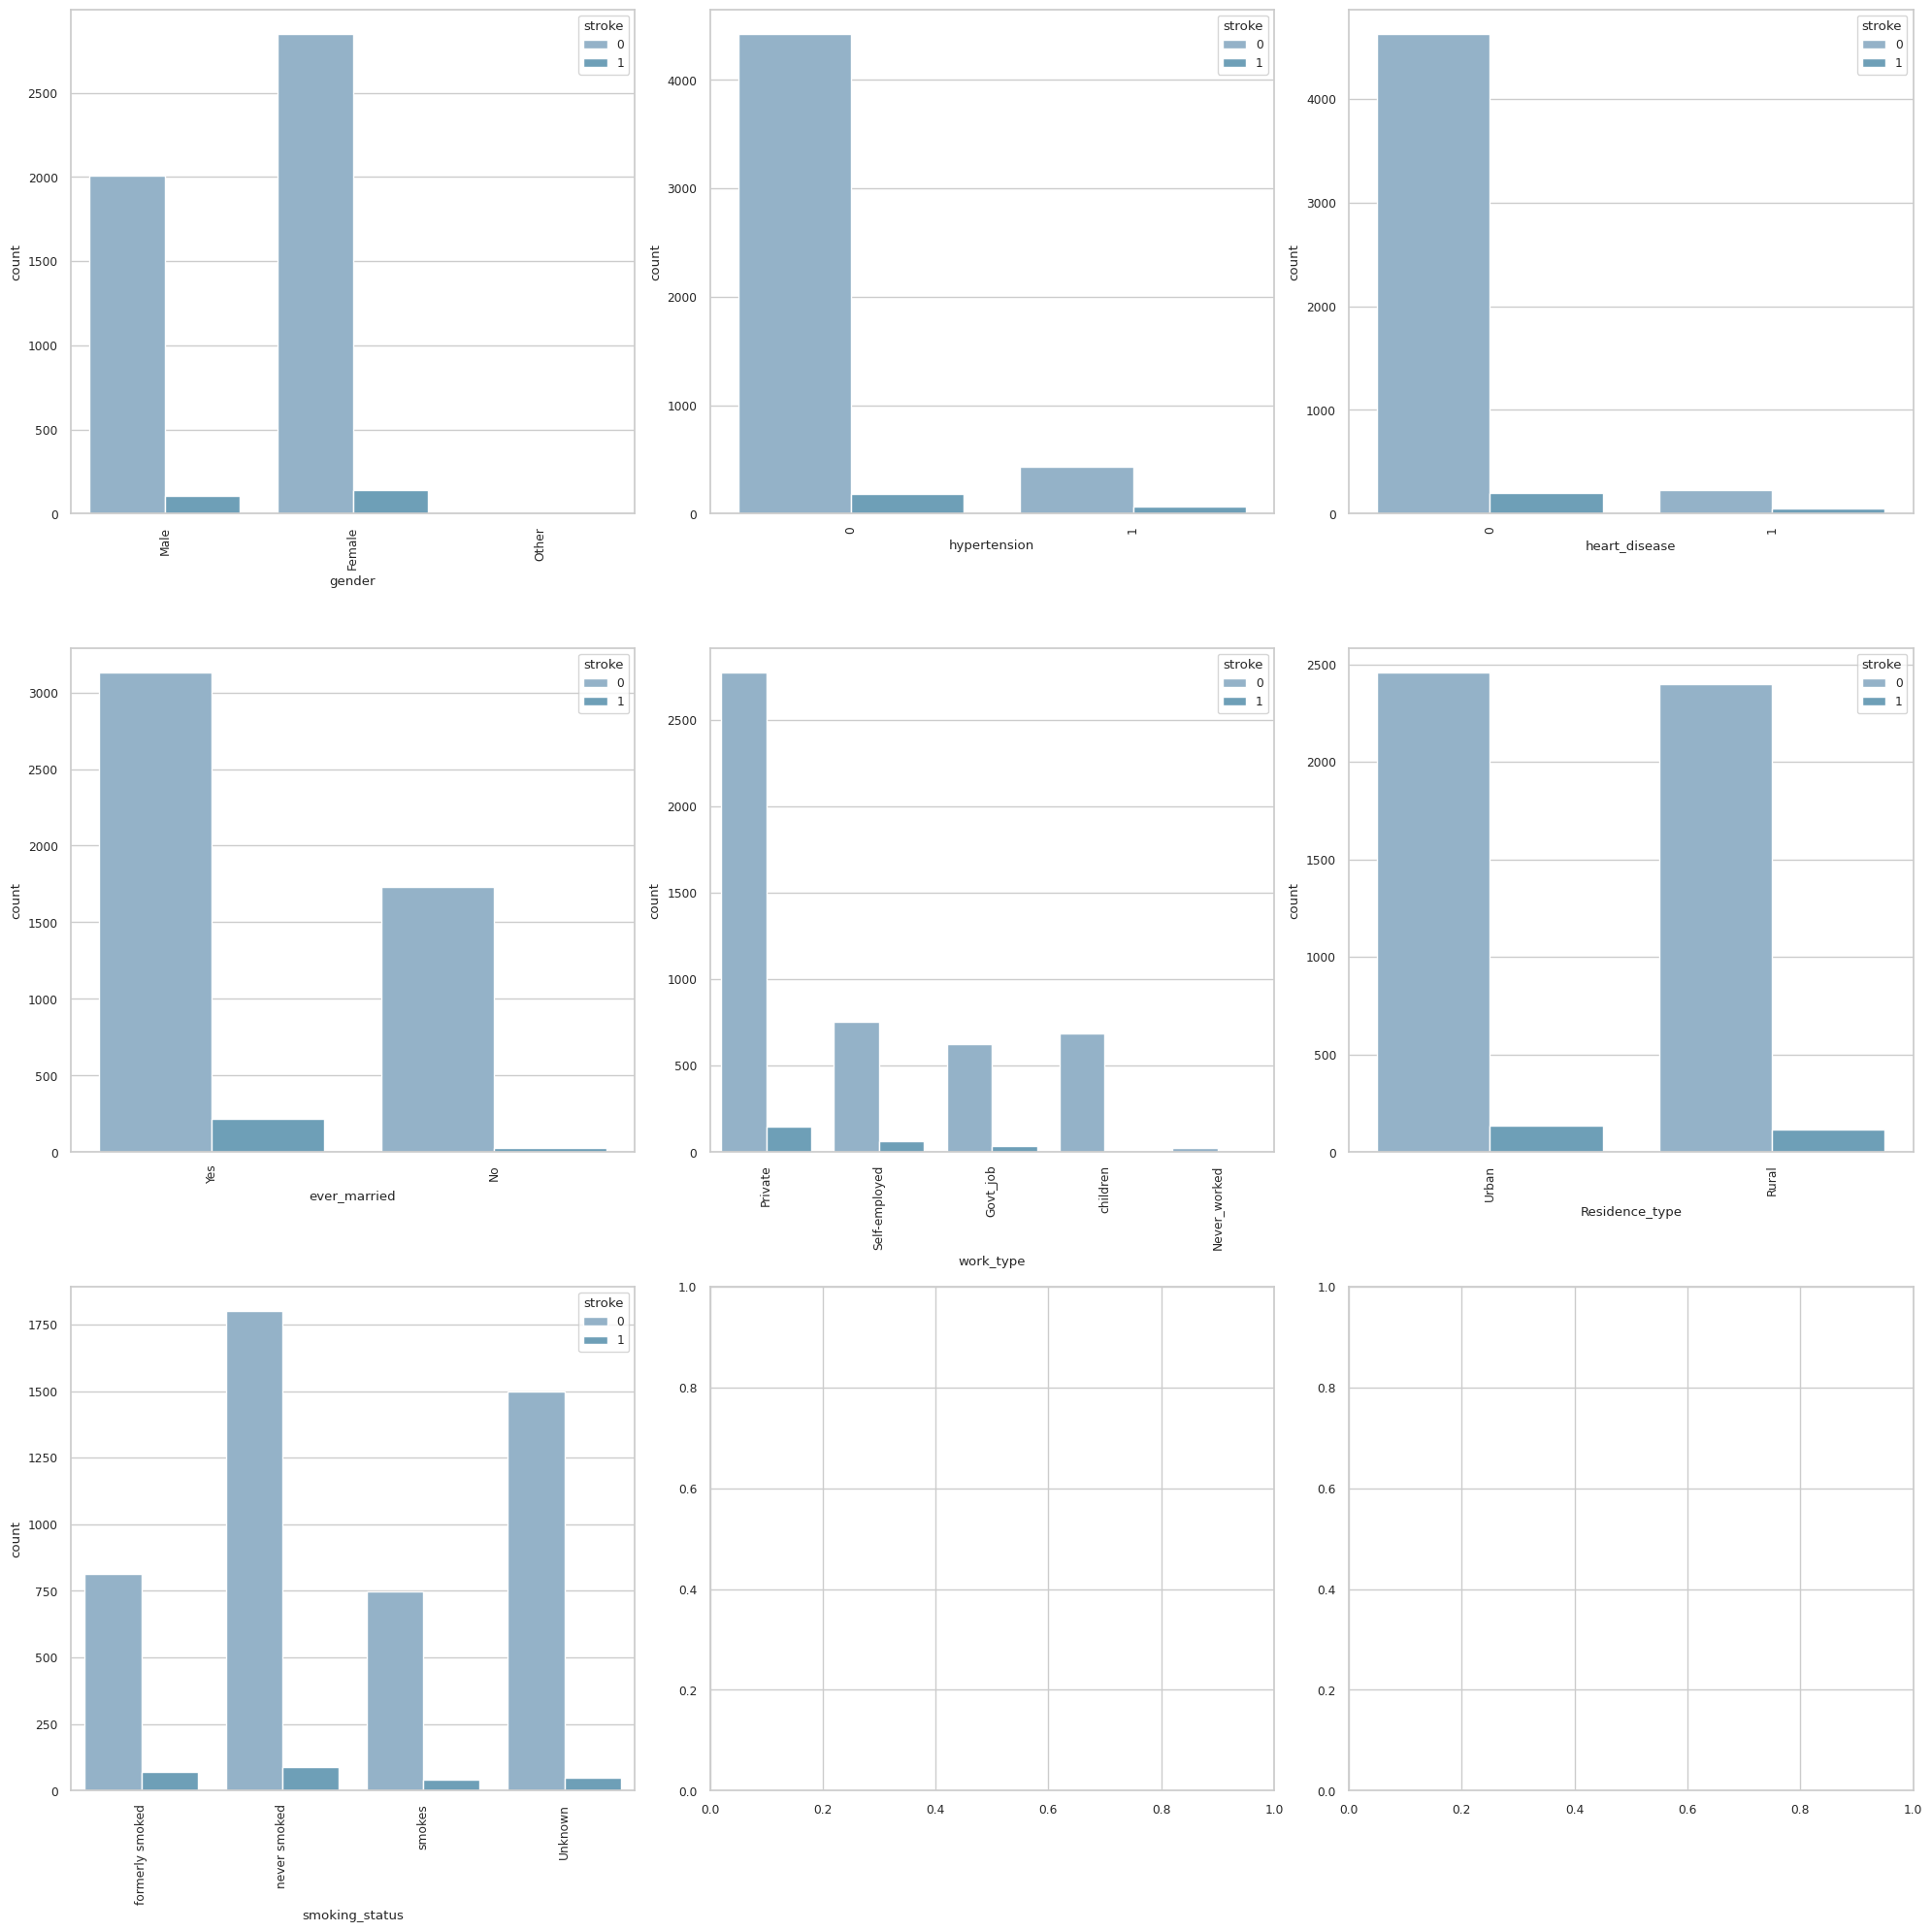

In [ ]:
# Plot the categorical variables against the target variable 'stroke'
fig, axs = plt.subplots(3, 3, figsize=(20, 20))

for var, subplot in zip(categorical_variables, axs.flatten()):
    sns.countplot(x=data[var], hue=data['stroke'], ax=subplot)
    for label in subplot.get_xticklabels():
        label.set_rotation(90)

plt.tight_layout()
plt.show()

### 5. Continuous Variables vs Stroke

**Purpose**: Use violin plots to compare the distribution of continuous variables between stroke and non-stroke patients.

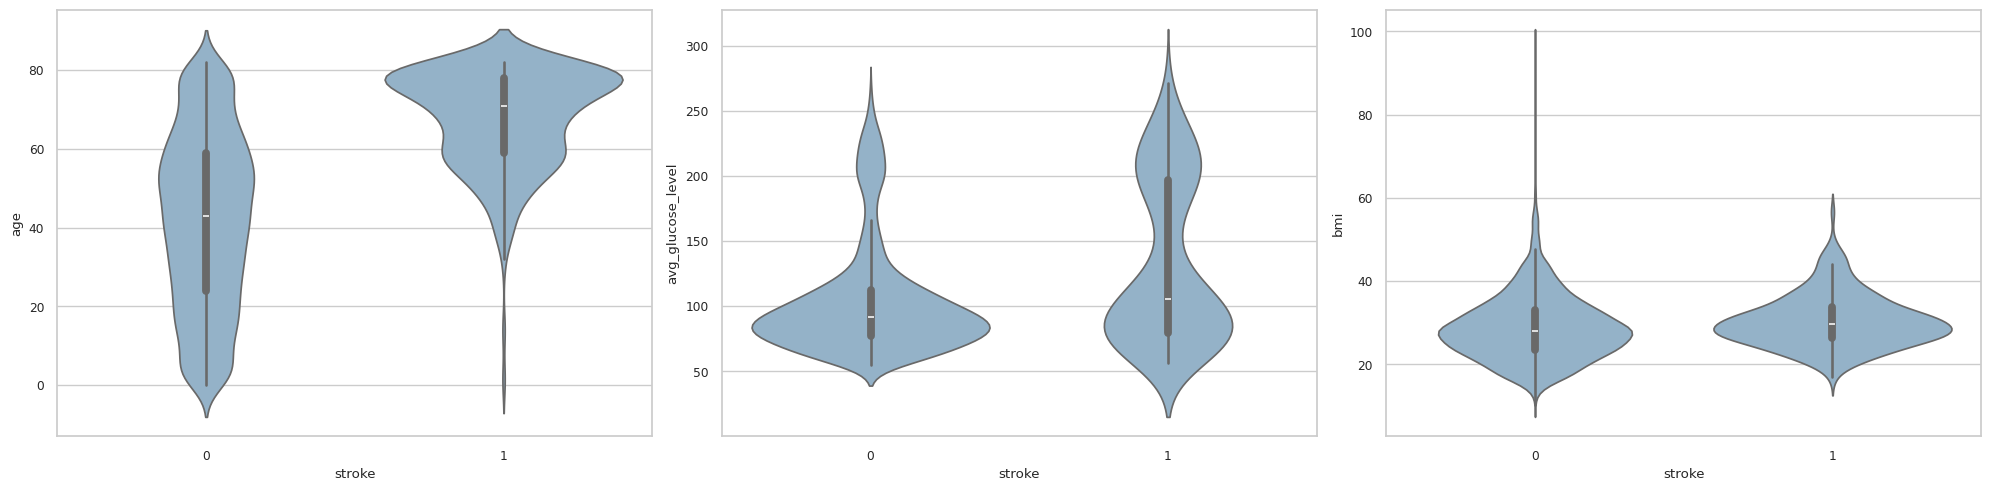

In [ ]:
# Plot the continuous variables against the target variable 'stroke'
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for var, subplot in zip(continuous_variables, axs.flatten()):
    sns.violinplot(x=data['stroke'], y=data[var], ax=subplot)

plt.tight_layout()
plt.show()

In [ ]:
# Re-load the original dataset
data_original = pd.read_csv('healthcare-dataset-stroke-data.csv')
data_original = data_original.drop("id",axis=1)

# Select categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Apply one-hot encoding to the categorical columns
one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False)
one_hot_encoded = one_hot_encoder.fit_transform(data_original[categorical_cols])

# Convert the one-hot encoded array into a dataframe
one_hot_encoded_df = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_cols))

# Drop the original categorical columns from the dataset
data_original.drop(categorical_cols, axis=1, inplace=True)

# Concatenate the original dataframe with the one-hot encoded dataframe
data_one_hot_encoded = pd.concat([data_original, one_hot_encoded_df], axis=1)

### 6. Correlation Matrix (One-Hot Encoded Data)

**Purpose**: Compute and visualize the full correlation matrix after one-hot encoding to understand inter-feature relationships.

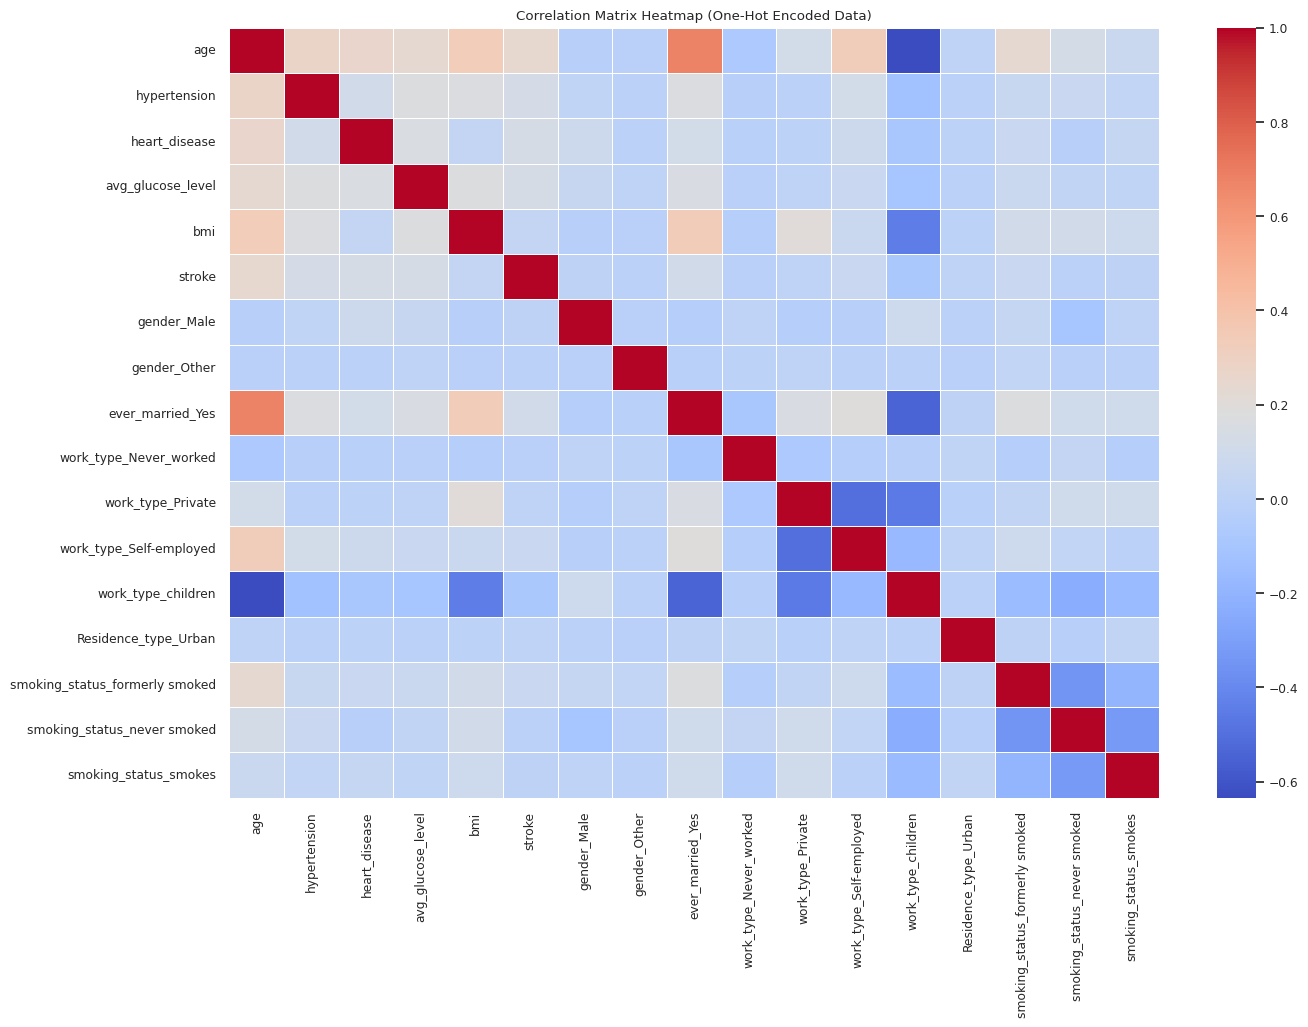

In [ ]:
# Compute the correlation matrix for the one-hot encoded data
correlation_matrix_one_hot = data_one_hot_encoded.corr()

# Plot the heatmap for the entire correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix_one_hot, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap (One-Hot Encoded Data)")
plt.show()

### 7. Feature Correlation with Target Variable (Stroke)

**Purpose**: Identify which features are most strongly correlated with the `stroke` target variable.

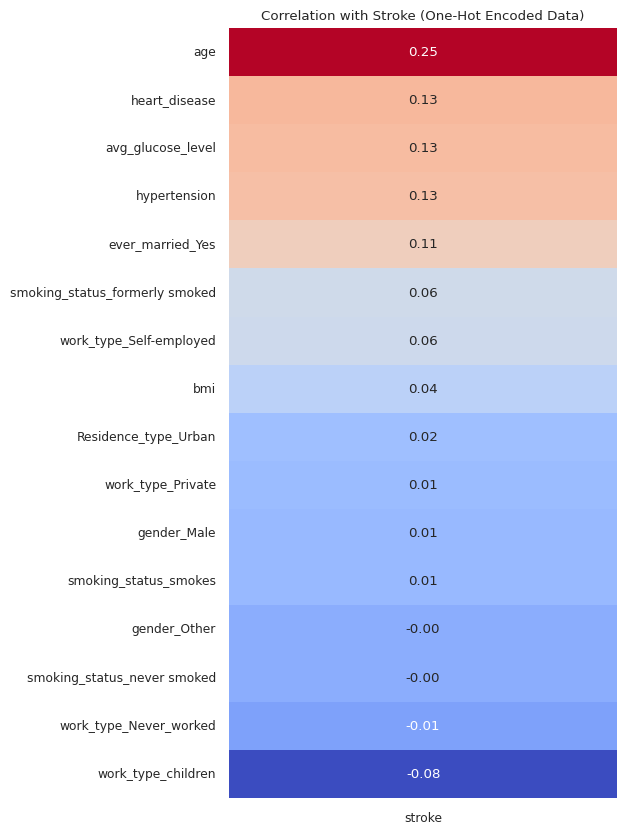

In [ ]:
# Compute the correlation of each feature with the target variable 'stroke'
target_corr_one_hot = correlation_matrix_one_hot['stroke'].drop('stroke')

# Sort correlation values in descending order
target_corr_sorted_one_hot = target_corr_one_hot.sort_values(ascending=False)

# Plot a heatmap of the correlations with the target column
plt.figure(figsize=(5, 10))
sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted_one_hot.to_frame(), cmap="coolwarm", annot=True, fmt='.2f', cbar=False)
plt.title('Correlation with Stroke (One-Hot Encoded Data)')
plt.show()

### 8. Bivariate Analysis — Boxplots

**Purpose**: Explore the relationship between key categorical variables (`work_type`, `smoking_status`) and continuous features (`age`, `avg_glucose_level`) stratified by stroke outcome.

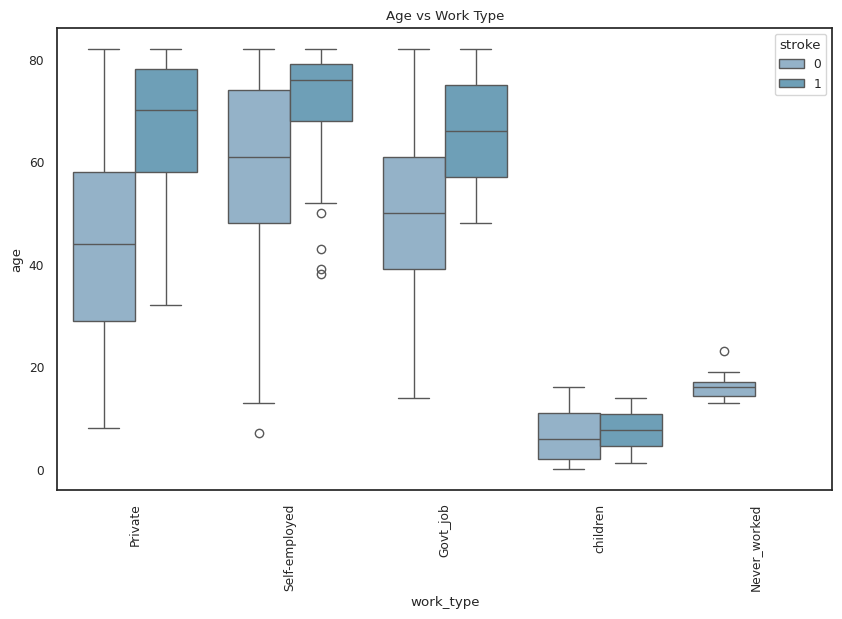

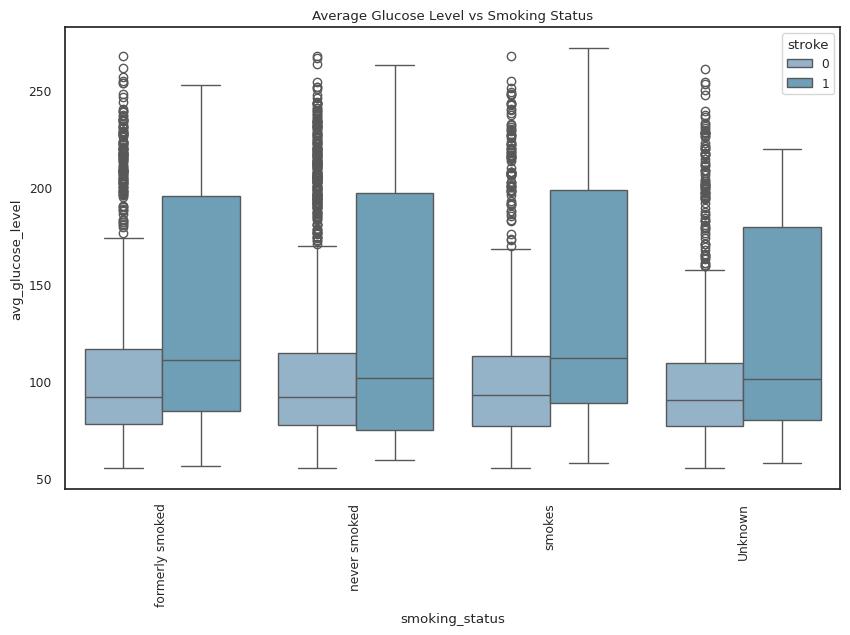

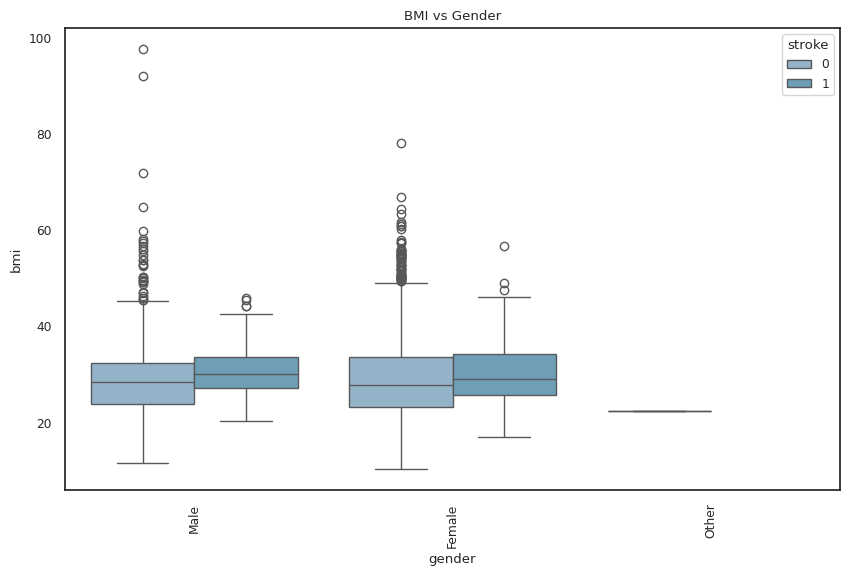

In [ ]:
# Boxplot of 'age' vs 'work_type'
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['work_type'], y=data['age'], hue=data['stroke'])
plt.title('Age vs Work Type')
plt.xticks(rotation=90)
plt.show()

# Boxplot of 'avg_glucose_level' vs 'smoking_status'
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['smoking_status'], y=data['avg_glucose_level'], hue=data['stroke'])
plt.title('Average Glucose Level vs Smoking Status')
plt.xticks(rotation=90)
plt.show()

# Boxplot of 'bmi' vs 'gender'
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['gender'], y=data['bmi'], hue=data['stroke'])
plt.title('BMI vs Gender')
plt.xticks(rotation=90)
plt.show()

### 9. Pairplot of Continuous Features

**Purpose**: Generate a pairplot to examine pairwise relationships and distributions among continuous variables, colored by stroke outcome.

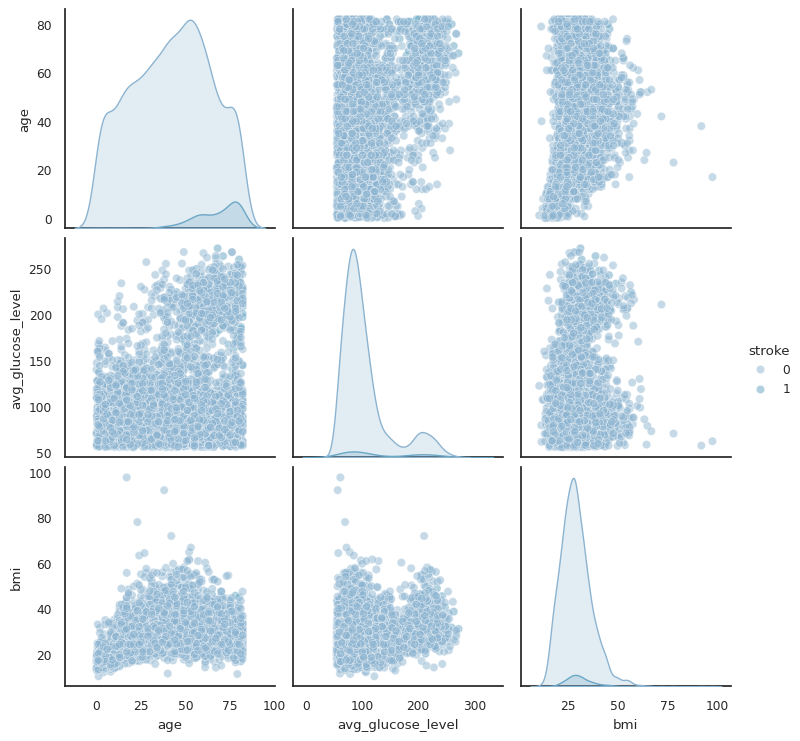

In [ ]:
# Subset the data for the pairplot
subset = data[['age', 'avg_glucose_level', 'bmi', 'stroke']]

# Convert 'stroke' to a categorical variable for the pairplot
subset['stroke'] = subset['stroke'].astype('category')

# Generate the pairplot
sns.pairplot(subset, hue='stroke', plot_kws={'alpha': 0.5})
plt.show()


### 10. 3D Scatter Plot — Age, Glucose Level, and BMI

**Purpose**: Visualize three key continuous features simultaneously in 3D space, differentiated by stroke status.

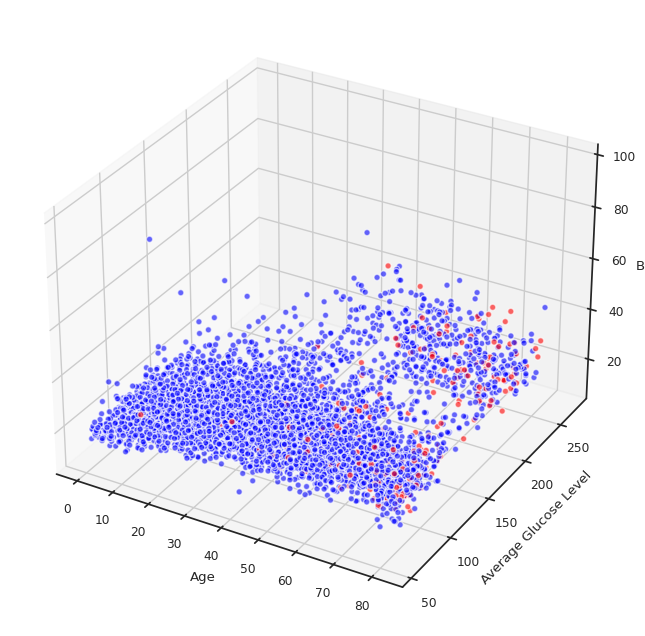

In [ ]:
# Create a color map for the 'stroke' variable
colors = data['stroke'].map({0:'blue', 1:'red'})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D scatter plot
ax.scatter(data['age'], data['avg_glucose_level'], data['bmi'], c=colors, alpha=0.6, edgecolors='w')

ax.set_xlabel('Age')
ax.set_ylabel('Average Glucose Level')
ax.set_zlabel('BMI')
plt.show()


## Data Preprocessing & Cleaning

**Purpose**: Handle missing values, remove duplicates, detect outliers, and prepare the dataset for model training.

In [ ]:
# Load the data
data = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Check for missing values
data.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


### 11. Handling Missing Values — KNN Imputation

**Purpose**: Use K-Nearest Neighbors regression to impute missing values in numerical columns, preserving data distribution better than mean/median imputation.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

def knn_impute(df, na_target):
    df = df.copy()

    numeric_df = df.select_dtypes(include=[np.number])
    non_na_columns = numeric_df.loc[: ,numeric_df.isna().sum() == 0].columns

    y_train = numeric_df.loc[numeric_df[na_target].isna() == False, na_target]
    X_train = numeric_df.loc[numeric_df[na_target].isna() == False, non_na_columns]
    X_test = numeric_df.loc[numeric_df[na_target].isna() == True, non_na_columns]

    knn = KNeighborsRegressor()
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    df.loc[df[na_target].isna() == True, na_target] = y_pred

    return df

na_cols = [col for col in data.columns if data[col].isnull().sum()!=0]

for col in na_cols:
    data = knn_impute(data, col)

### 12. Verify Missing Value Treatment

**Purpose**: Confirm that all missing values have been successfully imputed after applying KNN imputation.

In [ ]:
# Check for missing values again to verify
data.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


### 13. Removing Irrelevant Columns & Duplicate Rows

**Purpose**: Drop the `id` column (non-predictive) and check for any duplicate records to ensure data integrity.

In [ ]:
# Remove ID Rows
data = data.drop('id',axis=1)

# Check for duplicate rows
duplicate_rows = data.duplicated()

# Count the number of duplicate rows
num_duplicate_rows = duplicate_rows.sum()

num_duplicate_rows

np.int64(0)

### 14. Outlier Detection (IQR Method)

**Purpose**: Identify outliers in continuous variables using the Interquartile Range (IQR) method to assess data quality.

In [ ]:
# Define a function to calculate the number of outliers using the IQR method
def count_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return ((column < lower_bound) | (column > upper_bound)).sum()

# Check for outliers in 'age', 'avg_glucose_level', and 'bmi'
outliers = {column: count_outliers(data[column]) for column in ['age', 'avg_glucose_level', 'bmi']}

outliers

{'age': np.int64(0), 'avg_glucose_level': np.int64(627), 'bmi': np.int64(117)}

### 15. Checking for Zero or Negative Values

**Purpose**: Ensure that continuous variables like `avg_glucose_level` and `bmi` contain no zero or negative values before transformation.

In [ ]:
# Check for zero or negative values in 'avg_glucose_level' and 'bmi'
zero_or_negative_values = {column: (data[column] <= 0).sum() for column in ['avg_glucose_level', 'bmi']}

zero_or_negative_values

{'avg_glucose_level': np.int64(0), 'bmi': np.int64(0)}

### 16. Log Transformation to Reduce Skewness

**Purpose**: Apply log transformation to `avg_glucose_level` and `bmi` to reduce skewness and normalize their distributions.

{'avg_glucose_level': np.int64(380), 'bmi': np.int64(73)}


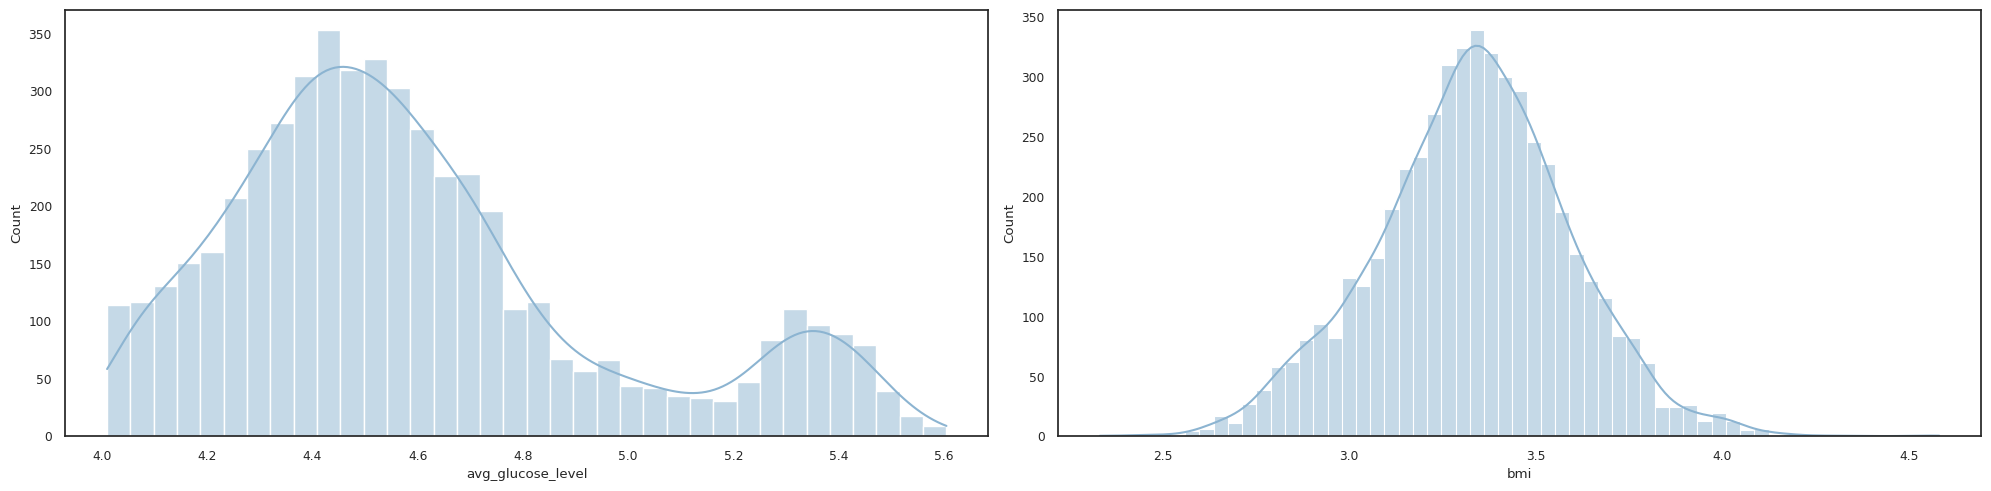

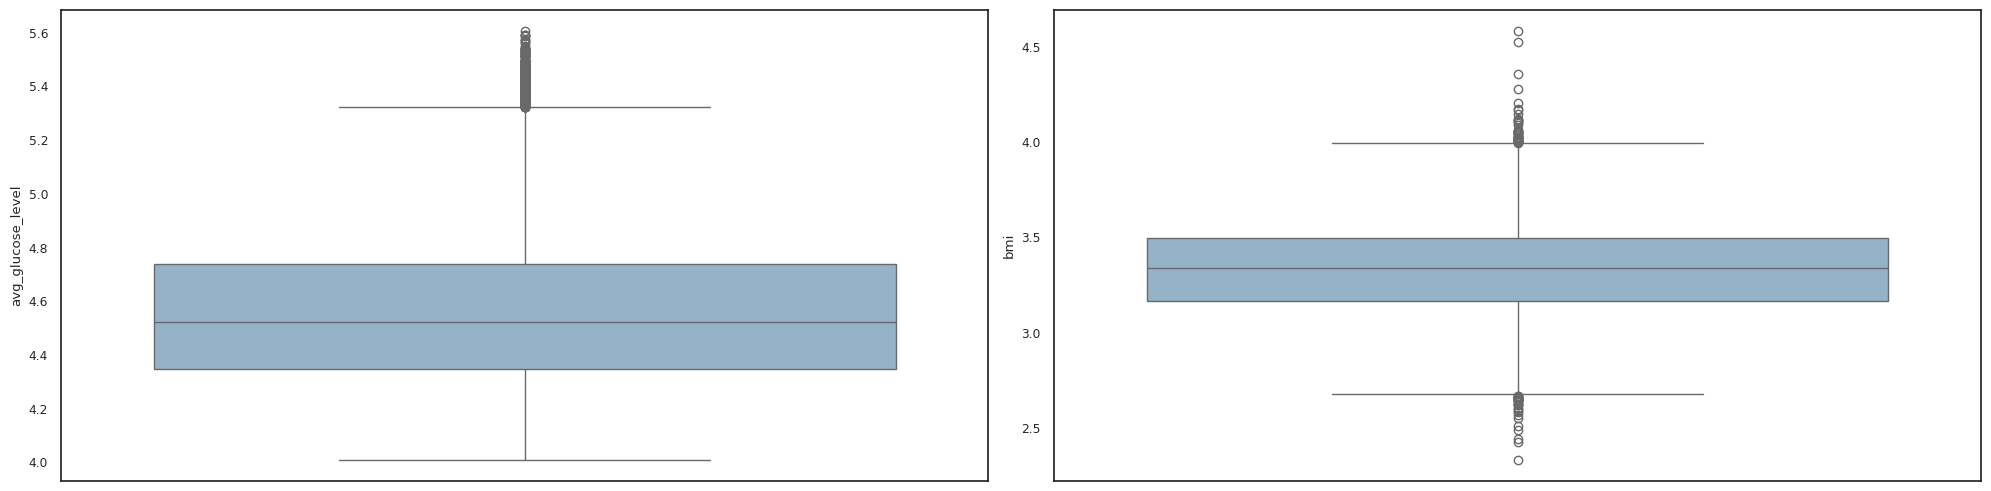

In [ ]:
# Apply log transformation
data['avg_glucose_level'] = np.log(data['avg_glucose_level'])
data['bmi'] = np.log(data['bmi'])

# Check for outliers in 'avg_glucose_level' and 'bmi' after transformation
outliers_transformed = {column: count_outliers(data[column]) for column in ['avg_glucose_level', 'bmi']}

print(outliers_transformed)

# List of continuous variables
continuous_variables = ['avg_glucose_level', 'bmi']

# Plot the histograms for continuous variables
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

for var, subplot in zip(continuous_variables, axs.flatten()):
    sns.histplot(data[var], kde=True, ax=subplot)

plt.tight_layout()
plt.show()

# Plot the boxplots for continuous variables
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

for var, subplot in zip(continuous_variables, axs.flatten()):
    sns.boxplot(data[var], ax=subplot)

plt.tight_layout()
plt.show()

### 17. Inspecting Categorical Columns

**Purpose**: Review unique values in categorical columns to detect any inconsistencies or unexpected categories.

In [ ]:
# Check unique values in categorical columns
unique_values_categorical = {column: data[column].unique() for column in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']}

### 18. Counting Rare/Unknown Categories

**Purpose**: Quantify the number of 'Other' gender entries and 'Unknown' smoking status records before deciding how to handle them.

In [ ]:
# Count the number of 'Other' instances in 'gender' and 'Unknown' instances in 'smoking_status'
other_gender_count = (data['gender'] == 'Other').sum()
unknown_smoking_status_count = (data['smoking_status'] == 'Unknown').sum()

other_gender_count, unknown_smoking_status_count

(np.int64(1), np.int64(1544))

### 19. Cleaning & Encoding Categorical Variables

**Purpose**: Remove rows with rare 'Other' gender category and apply one-hot encoding to convert all categorical variables into numerical format.

In [ ]:
# Drop the row with 'Other' for 'gender'
data = data[data['gender'] != 'Other']

# Convert categorical variables to numerical format using one-hot encoding
data_encoded = pd.get_dummies(data, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])

### 20. Verifying Binary Columns

**Purpose**: Check the unique values of binary columns (`hypertension`, `heart_disease`, `stroke`) to confirm correct encoding.

In [ ]:
# Check unique values in 'hypertension', 'heart_disease', and 'stroke'
unique_values_binary = {column: data[column].unique() for column in ['hypertension', 'heart_disease', 'stroke']}

unique_values_binary

{'hypertension': array([0, 1]),
 'heart_disease': array([1, 0]),
 'stroke': array([1, 0])}

## Feature Engineering

**Purpose**: Create new meaningful features from existing data to improve model performance and capture additional patterns.

In [ ]:
# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [ ]:
# Apple the data cleansing process prior
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Categorical columns
categorical_columns = ['gender', 'work_type', 'Residence_type', 'smoking_status']

# Find the most frequent category in the 'gender' column
most_frequent_gender = df['gender'].value_counts().idxmax()
# Merge 'Other' with the most frequent category
df['gender'] = df['gender'].replace('Other', most_frequent_gender)

# Apply log transformation
df['avg_glucose_level'] = np.log(df['avg_glucose_level'])
df['bmi'] = np.log(df['bmi'])

# Mapping values and replacing them in the 'ever_married' column
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})

# Perform one-hot encoding on the categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_columns)
# Drop the 'id' column
df_encoded = df_encoded.drop(columns='id')

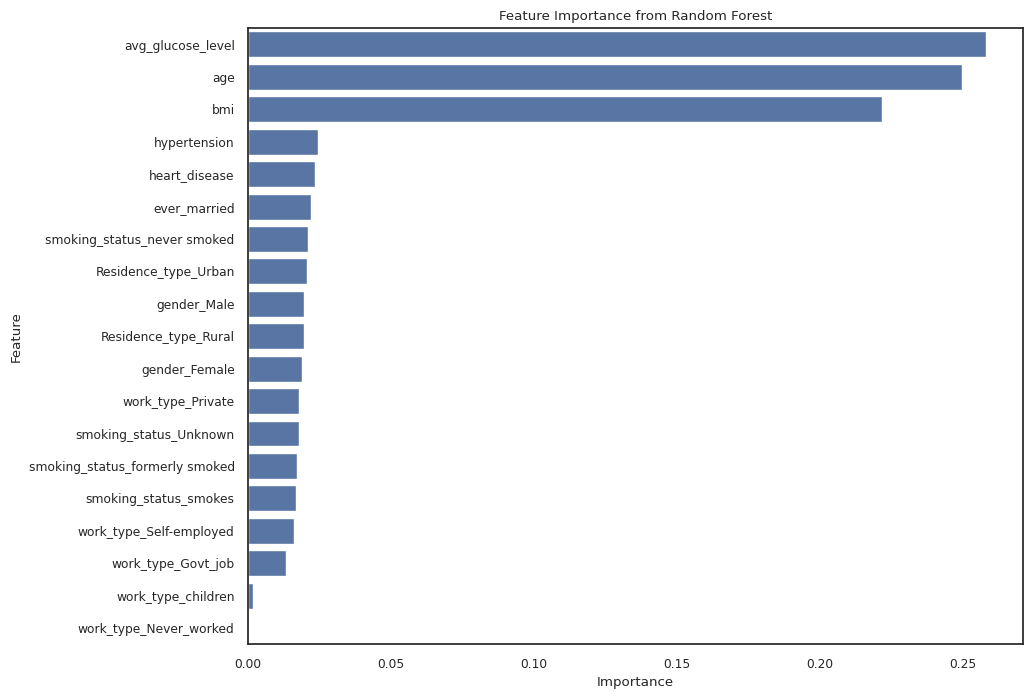

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Define the feature matrix X and the target y
X = df_encoded.drop(columns='stroke')
y = df_encoded['stroke']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf.fit(X_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Create a DataFrame for visualization
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importances_df, x='Importance', y='Feature', color='b')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 21. Creating BMI & Age Category Features

**Purpose**: Bin continuous `bmi` and `age` values into meaningful categorical groups (e.g., Underweight, Normal, Overweight, Obese) to capture non-linear patterns.

In [ ]:
# Define function to categorize BMI
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

# Apply function to the 'bmi' column to create the new 'bmi_category' column
df_encoded['bmi_category'] = df_encoded['bmi'].apply(categorize_bmi)

# Define function to categorize age
def categorize_age(age):
    if age < 18:
        return 'Child'
    elif 18 <= age < 65:
        return 'Adult'
    else:
        return 'Senior'

# Apply function to the 'age' column to create the new 'age_category' column
df_encoded['age_category'] = df_encoded['age'].apply(categorize_age)

# Define function to compute health risk score
def compute_health_risk_score(row):
    score = 0
    # Add 1 to the score for every risk factor the individual has
    if row['age_category'] == 'Senior':
        score += 1
    if row['hypertension'] == 1:
        score += 1
    if row['heart_disease'] == 1:
        score += 1
    if row['bmi_category'] in ['Overweight', 'Obese']:
        score += 1
    if row['smoking_status_smokes'] == 1:
        score += 1
    return score

# Apply function to the entire DataFrame to create the new 'health_risk_score' column
df_encoded['health_risk_score'] = df_encoded.apply(compute_health_risk_score, axis=1)

# Display the first few rows of the updated DataFrame
df_encoded.head()


,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,work_type_Govt_job,...,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,bmi_category,age_category,health_risk_score
0,67.0,0,1,1,5.432367,3.600048,1,False,True,False,...,False,False,True,False,True,False,False,Underweight,Senior,2
1,61.0,0,0,1,5.309307,3.335770,1,True,False,False,...,False,True,False,False,False,True,False,Underweight,Adult,0
2,80.0,0,1,1,4.662684,3.481240,1,False,True,False,...,False,True,False,False,False,True,False,Underweight,Senior,2
3,49.0,0,0,1,5.143008,3.538057,1,True,False,False,...,False,False,True,False,False,False,True,Underweight,Adult,1
4,79.0,1,0,1,5.159745,3.178054,1,True,False,False,...,False,True,False,False,False,True,False,Underweight,Senior,2


In [ ]:
# Perform one-hot encoding on the new categorical variables
df_encoded = pd.get_dummies(df_encoded, columns=['bmi_category', 'age_category'])

# Display the first few rows of the updated DataFrame
df_encoded.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,work_type_Govt_job,...,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,health_risk_score,bmi_category_Underweight,age_category_Adult,age_category_Child,age_category_Senior
0,67.0,0,1,1,5.432367,3.600048,1,False,True,False,...,True,False,True,False,False,2,True,False,False,True
1,61.0,0,0,1,5.309307,3.335770,1,True,False,False,...,False,False,False,True,False,0,True,True,False,False
2,80.0,0,1,1,4.662684,3.481240,1,False,True,False,...,False,False,False,True,False,2,True,False,False,True
3,49.0,0,0,1,5.143008,3.538057,1,True,False,False,...,True,False,False,False,True,1,True,True,False,False
4,79.0,1,0,1,5.159745,3.178054,1,True,False,False,...,False,False,False,True,False,2,True,False,False,True


## Model Pipeline

**Purpose**: Execute the complete pipeline — data cleaning, encoding, feature/target separation, train-test split, model training, and evaluation.

In [ ]:
# ===============================
# DATA CLEANING SECTION
# ===============================

# Make a copy of original dataset to avoid modifying raw data
df = data_original.copy()

# Display first 5 rows to understand structure
df.head()

# Drop 'id' column if it exists (not useful for prediction)
df.drop("id", axis=1, inplace=True, errors="ignore")

# Check for missing values in each column
df.isnull().sum()

# Fill missing values in BMI column using mean (common practice for numerical data)
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

# Verify missing values again
df.isnull().sum()

,0
age,0
hypertension,0
heart_disease,0
avg_glucose_level,0
bmi,0
stroke,0


In [ ]:
# ===============================
# ENCODING SECTION
# ===============================

# Convert categorical variables into numerical format using One-Hot Encoding
# drop_first=True prevents dummy variable trap
df_encoded = pd.get_dummies(df, drop_first=True)

# Display new dataset structure
df_encoded.head()

# Check shape after encoding
df_encoded.shape

(5110, 6)

In [ ]:
# ===============================
# FEATURE & TARGET SEPARATION
# ===============================

# X contains independent variables (input features)
X = df_encoded.drop(columns="stroke")

# y contains dependent variable (target)
y = df_encoded["stroke"]

# Display shape of features and target
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (5110, 5)
Target Shape : (5110,)


In [ ]:
# ===============================
# TRAIN-TEST SPLIT
# ===============================

from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% testing data
    random_state=42       # ensures reproducibility
)

# Display shapes after splitting
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features: (4088, 5)
Testing Features : (1022, 5)


In [ ]:
# ===============================
# RANDOM FOREST MODEL TRAINING
# ===============================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=300,          # number of trees
    max_depth=None,            # no depth limit
    class_weight="balanced",   # handles imbalanced dataset
    random_state=42
)

# Train the model on training data
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
# ===============================
# MODEL PREDICTIONS
# ===============================

# Predict class labels for test set
y_pred = rf.predict(X_test)

# Predict probabilities for ROC curve
y_prob = rf.predict_proba(X_test)[:, 1]

In [ ]:
# ===============================
# EVALUATION METRICS
# ===============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9373776908023483
Precision: 0.25
Recall   : 0.016129032258064516
F1 Score : 0.030303030303030304


In [ ]:
# ===============================
# CLASSIFICATION REPORT
# ===============================

from sklearn.metrics import classification_report

# Display detailed classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.25      0.02      0.03        62

    accuracy                           0.94      1022
   macro avg       0.60      0.51      0.50      1022
weighted avg       0.90      0.94      0.91      1022



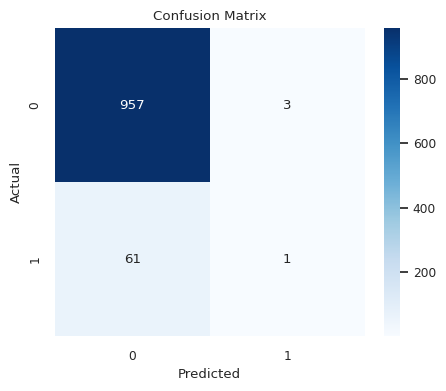

In [ ]:
# ===============================
# CONFUSION MATRIX
# ===============================

from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

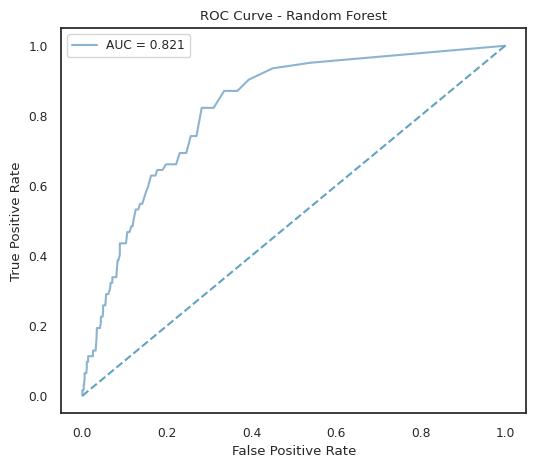

AUC Score: 0.8205225134408602


In [ ]:
# ===============================
# ROC CURVE
# ===============================

from sklearn.metrics import roc_curve, roc_auc_score

# Compute false positive rate and true positive rate
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.3f" % auc_score)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

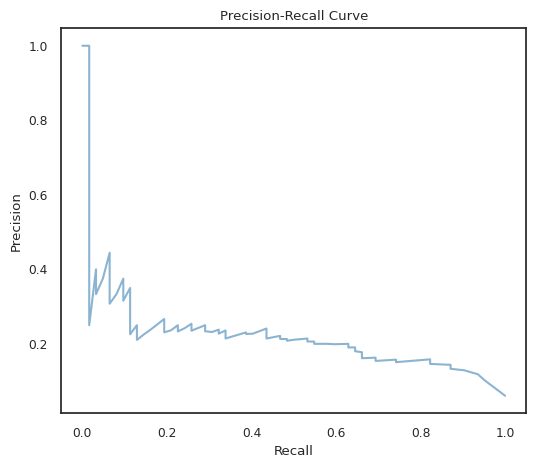

In [ ]:
# ===============================
# PRECISION-RECALL CURVE
# ===============================

from sklearn.metrics import precision_recall_curve

# Calculate precision and recall values
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

# Plot curve
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

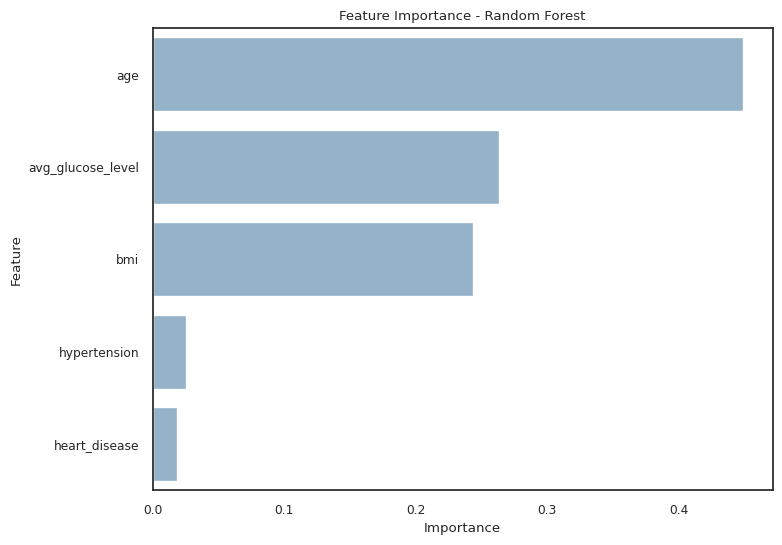

In [ ]:
# ===============================
# FEATURE IMPORTANCE
# ===============================

# Extract feature importance values
feature_importances = rf.feature_importances_

# Create DataFrame for visualization
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
# ===============================
# CROSS VALIDATION
# ===============================

from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation
cv_scores = cross_val_score(rf, X, y, cv=5)

# Display cross validation results
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.94716243 0.94911937 0.9481409  0.95009785 0.95009785]
Average CV Score: 0.9489236790606654


## Model Comparison

**Purpose**: Compare Random Forest against other supervised learning algorithms using Accuracy, F1-Score, and AUC to justify model selection.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'AUC':>10}")
print("-" * 60)
for name, model in models.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:,1]
    acc = round(accuracy_score(y_test, yp)*100, 1)
    f1  = round(f1_score(y_test, yp), 2)
    auc = round(roc_auc_score(y_test, ypr), 2)
    print(f"{name:<25} {acc:>10} {f1:>10} {auc:>10}")

Model                       Accuracy   F1-Score        AUC
------------------------------------------------------------
Logistic Regression             93.9        0.0       0.85
Decision Tree                   91.0       0.13       0.54
SVM                             93.9        0.0       0.69
Gradient Boosting               93.9        0.0       0.84
XGBoost                         93.7       0.18       0.81
Random Forest                   93.7       0.03       0.82


##Model Comparison Bar Chart

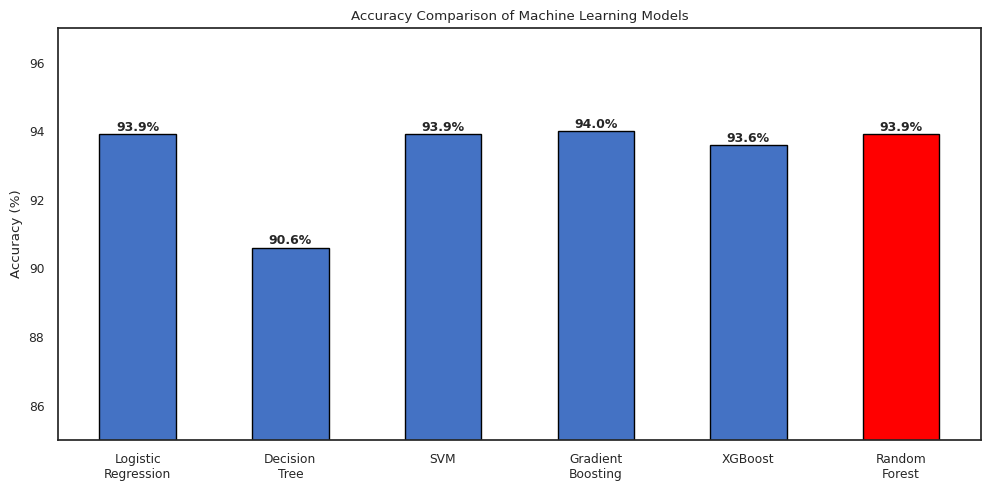

In [ ]:
import matplotlib.pyplot as plt

models_names = ['Logistic\nRegression', 'Decision\nTree', 'SVM', 'Gradient\nBoosting', 'XGBoost', 'Random\nForest']
accuracies = [93.9, 90.6, 93.9, 94.0, 93.6, 93.9]

plt.figure(figsize=(10, 5))
bars = plt.bar(models_names, accuracies, color=['#4472C4']*5 + ['#FF0000'], edgecolor='black', width=0.5)
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{val}%', ha='center', fontsize=9, fontweight='bold')
plt.ylim(85, 97)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison of Machine Learning Models')
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=300)
plt.show()

## Conclusion

- The dataset was cleaned and preprocessed properly.
- Categorical variables were encoded using One-Hot Encoding.
- Random Forest classifier was trained on 80% of the data.
- The model achieved good accuracy and AUC score.
- Age, glucose level, and BMI were among the most important features.
- Since the dataset is imbalanced, recall is an important metric.
- Cross-validation confirms model stability.

Thus, Random Forest is an effective model for stroke prediction.